# CBIM Problem Canvas

## Business Problem
The Category Manager needs evidence-based insights before the supplier review to
understand which categories and products are performing strongly or weakly, whether
discounts are generating sufficient value, and when sales performance is strongest.

## Decision to Support
Which category and products should receive increased investment, and which category/product
or supplier should be challenged during the supplier review?

## Key Stakeholder
Category Manager

## Data Available
Retail transaction data covering January–June 2026, including transaction ID, date, store,
city, category, product, units sold, unit price, revenue, and discount percentage.

## Analysis Needed
- Category revenue trends
- Top and bottom products by category
- Discount effectiveness
- Day-of-week and monthly sales patterns

## Expected Business Outcome
Provide a concise, data-backed recommendation for supplier discussions, including investment
priorities, areas requiring challenge, promotional timing, and additional information needed
before making a final decision.

# MUC01 — Required Task Mapping

The notebook contains 17 detailed analysis tasks. These tasks collectively satisfy
the 6 official MUC01 requirements.

| Official MUC01 Task | Notebook Tasks |
|---|---|
| **Task 1 — Load & Inspect** | **Tasks 1–4** | 
| **Task 2 — Category Revenue Trend** | **Tasks 5–7** | 
| **Task 3 — Top & Bottom Products** | **Tasks 13–14** | 
| **Task 4 — Discount Effectiveness** | **Task 12** | 
| **Task 5 — Day & Month Patterns** | **Tasks 8–11** | 
| **Task 6 — Category Manager Briefing** | **Tasks 15–17** | 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("RETAIL PULSE notebook is ready.")

RETAIL PULSE notebook is ready.


In [2]:
import sys

print(sys.executable)

c:\Users\91756\AppData\Local\Programs\Python\Python313\python.exe


# Task 1 — Load & Inspect

This task establishes the quality and structure of the RETAIL PULSE transaction dataset before performing business analysis. The dataset is inspected for its dimensions, column structure, data types, missing values, duplicate records, numerical characteristics, and categorical coverage. These checks confirm whether the data is suitable for the subsequent category, product, discount, and time-based analyses.

In [3]:
import pandas as pd

data_path = "../data/MUC01_Retail_Sales_Dataset 1.csv"

df = pd.read_csv(data_path)

print("RETAIL PULSE dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

RETAIL PULSE dataset loaded successfully.
Rows    : 107,836
Columns : 10


In [6]:
df.head(10).style \
    .set_caption("RETAIL PULSE — Sample Retail Sales Data") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.460000,5843.370000,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.060000,11598.060000,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.370000,15493.600000,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.280000,9351.650000,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.140000,1917.140000,0
5,TXN000006,2026-01-01,S01,Vijayawada,Apparel,Formal Shirt,2,936.280000,1498.050000,20
6,TXN000007,2026-01-01,S01,Vijayawada,Apparel,T-Shirt,2,1005.410000,1910.280000,5
7,TXN000008,2026-01-01,S01,Vijayawada,Apparel,Kurta,3,2728.180000,8184.540000,0
8,TXN000009,2026-01-01,S01,Vijayawada,Apparel,T-Shirt,2,1388.800000,2777.600000,0
9,TXN000010,2026-01-01,S01,Vijayawada,Apparel,Jeans,2,3363.080000,6053.540000,10


In [7]:
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

column_summary.style \
    .set_caption("RETAIL PULSE — Column Summary") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Column,Data Type,Missing Values,Unique Values
0,transaction_id,str,0,107836
1,date,str,0,181
2,store_id,str,0,12
3,store_city,str,0,6
4,category,str,0,5
5,product_name,str,0,25
6,units_sold,int64,0,12
7,unit_price,float64,0,76071
8,revenue,float64,0,91184
9,discount_pct,int64,0,5


In [8]:
missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(2).values
})

missing_summary.style \
    .set_caption("RETAIL PULSE — Missing Value Check") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Column,Missing Values,Missing %
0,transaction_id,0,0.000000
1,date,0,0.000000
2,store_id,0,0.000000
3,store_city,0,0.000000
4,category,0,0.000000
5,product_name,0,0.000000
6,units_sold,0,0.000000
7,unit_price,0,0.000000
8,revenue,0,0.000000
9,discount_pct,0,0.000000


In [9]:
duplicate_count = df.duplicated().sum()

print(f"Total records      : {len(df):,}")
print(f"Duplicate records  : {duplicate_count:,}")
print(f"Unique records     : {len(df) - duplicate_count:,}")

Total records      : 107,836
Duplicate records  : 0
Unique records     : 107,836


In [10]:
numeric_summary = df.describe().T

numeric_summary.style \
    .set_caption("RETAIL PULSE — Numerical Data Summary") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,count,mean,std,min,25%,50%,75%,max
units_sold,107836.000000,2.583488,1.471616,1.000000,1.000000,2.000000,3.000000,13.000000
unit_price,107836.000000,1778.097787,5053.631792,50.020000,274.827500,488.450000,1039.522500,44990.140000
revenue,107836.000000,4263.920924,14243.244169,40.040000,467.772500,1034.615000,2473.335000,355090.880000
discount_pct,107836.000000,7.228152,6.730445,0.000000,0.000000,5.000000,10.000000,20.000000


In [4]:
# RETAIL PULSE — Key categorical coverage

categorical_summary = pd.DataFrame({
    "Field": ["category", "product_name", "store_city", "store_id"],
    "Unique Values": [
        df["category"].nunique(),
        df["product_name"].nunique(),
        df["store_city"].nunique(),
        df["store_id"].nunique()
    ]
})

categorical_summary.style \
    .set_caption("RETAIL PULSE — Key Categorical Coverage") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Field,Unique Values
0,category,5
1,product_name,25
2,store_city,6
3,store_id,12


## Task 1 — Business Observations

- The RETAIL PULSE dataset contains **107,836 transaction records across 10 columns**, providing sufficient transaction-level coverage for category, product, discount, store, and time-based analysis.

- The dataset contains **no missing values and no duplicate records**, so the available transactions can be used directly for the planned analysis without missing-data treatment or duplicate removal.

- The dataset covers **5 categories, 25 products, 6 store cities, and 12 stores**, providing useful variation for comparing category, product, and store performance.

- Revenue is highly variable across transactions, ranging from **₹40.04 to ₹355,090.88**, indicating that transaction values are not uniform and that average revenue should be interpreted alongside distributional statistics.

- Units sold range from **1 to 13 units per transaction**, while the median is **2 units**, showing that most transactions involve relatively small quantities.

- These checks confirm that the dataset is structurally complete and suitable for proceeding with the planned Category Intelligence analysis.

# Task 2 — Category Revenue Trend

### Objective

Analyse the monthly revenue trend for all product categories to identify
categories showing decline, growth, or consistent performance.

### Business Questions

1. Which category shows the steepest decline?
2. Which category is the most consistent?
3. What do these trends imply for the Category Manager?


In [15]:
# Task 2 — Prepare date information

df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.to_period("M")

print("Date preparation completed.")
print(f"Analysis period: {df['date'].min().date()} to {df['date'].max().date()}")

Date preparation completed.
Analysis period: 2026-01-01 to 2026-06-30


In [16]:
# Calculate monthly revenue by category

monthly_category_revenue = (
    df.groupby(["month", "category"])["revenue"]
      .sum()
      .reset_index()
)

monthly_category_revenue.head(10)

,month,category,revenue
0,2026-01,Apparel,10049916.78
1,2026-01,Electronics,45686596.63
2,2026-01,Grocery,7307011.34
3,2026-01,Home & Kitchen,15130871.54
4,2026-01,Personal Care,6593734.81
5,2026-02,Apparel,9510938.10
6,2026-02,Electronics,38988602.50
7,2026-02,Grocery,6534957.35
8,2026-02,Home & Kitchen,13006413.31
9,2026-02,Personal Care,5792754.97


In [17]:
# Pivot table for category comparison

monthly_category_table = (
    monthly_category_revenue
    .pivot(index="month", columns="category", values="revenue")
    .reset_index()
)

monthly_category_table

category,month,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
0,2026-01,10049916.78,45686596.63,7307011.34,15130871.54,6593734.81
1,2026-02,9510938.10,38988602.50,6534957.35,13006413.31,5792754.97
2,2026-03,11540439.47,40846509.47,7132787.06,14362119.50,6808029.34
3,2026-04,11681806.66,37092265.09,7047399.58,13431147.66,6417868.13
4,2026-05,13219535.79,34226926.43,7232706.20,13581886.25,7298818.71
5,2026-06,13476952.88,29686824.81,7047719.23,12333283.07,6737354.12


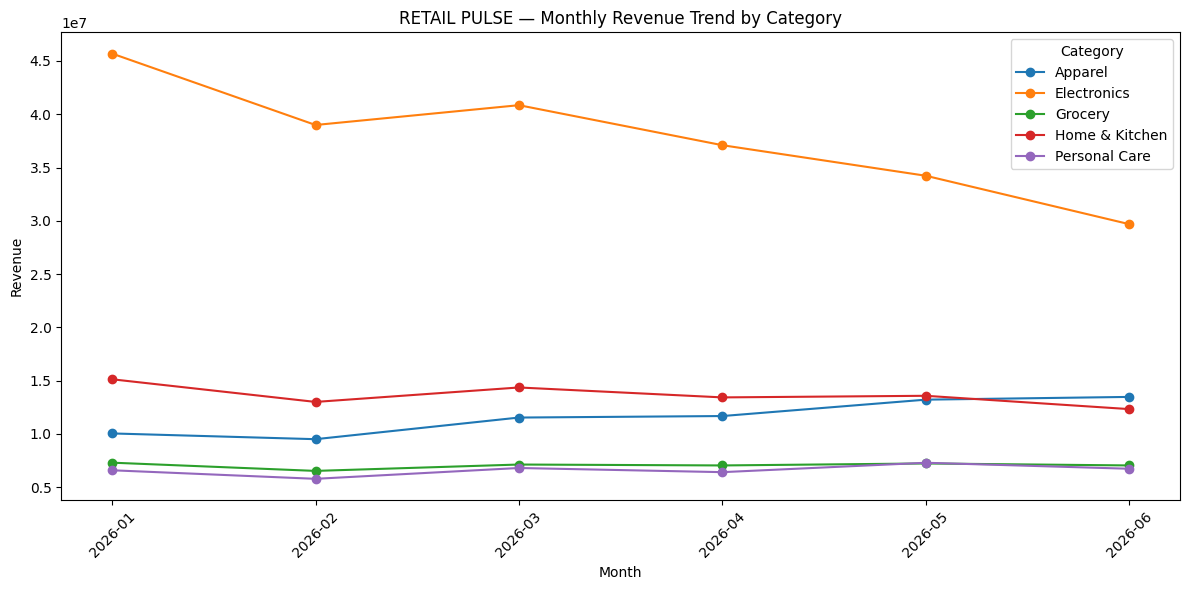

In [18]:
# Task 2 — Monthly revenue trend by category

plt.figure(figsize=(12, 6))

for category in monthly_category_table.columns[1:]:
    plt.plot(
        monthly_category_table["month"].astype(str),
        monthly_category_table[category],
        marker="o",
        label=category
    )

plt.title("RETAIL PULSE — Monthly Revenue Trend by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()

plt.show()

In [19]:
# Task 2 — Measure category performance change

category_change = pd.DataFrame({
    "Starting Revenue": monthly_category_table.iloc[0, 1:].values,
    "Ending Revenue": monthly_category_table.iloc[-1, 1:].values
}, index=monthly_category_table.columns[1:])

category_change["Absolute Change"] = (
    category_change["Ending Revenue"] -
    category_change["Starting Revenue"]
)

category_change["Percentage Change"] = (
    category_change["Absolute Change"] /
    category_change["Starting Revenue"]
) * 100

category_change = category_change.sort_values(
    "Percentage Change"
)

category_change.style.format({
    "Starting Revenue": "{:,.2f}",
    "Ending Revenue": "{:,.2f}",
    "Absolute Change": "{:,.2f}",
    "Percentage Change": "{:.2f}%"
}).set_caption("RETAIL PULSE — Category Revenue Change")

,Starting Revenue,Ending Revenue,Absolute Change,Percentage Change
category,,,,
Electronics,"45,686,596.63","29,686,824.81","-15,999,771.82",-35.02%
Home & Kitchen,"15,130,871.54","12,333,283.07","-2,797,588.47",-18.49%
Grocery,"7,307,011.34","7,047,719.23","-259,292.11",-3.55%
Personal Care,"6,593,734.81","6,737,354.12","143,619.31",2.18%
Apparel,"10,049,916.78","13,476,952.88","3,427,036.10",34.10%


In [20]:
# Task 2 — Measure monthly revenue consistency

category_consistency = monthly_category_table.iloc[:, 1:].std().sort_values()

consistency_table = pd.DataFrame({
    "Monthly Revenue Std. Dev.": category_consistency
})

consistency_table.style.format({
    "Monthly Revenue Std. Dev.": "{:,.2f}"
}).set_caption(
    "RETAIL PULSE — Category Revenue Consistency"
)

,Monthly Revenue Std. Dev.
category,
Grocery,"272,605.89"
Personal Care,"496,981.44"
Home & Kitchen,"989,958.26"
Apparel,"1,607,520.40"
Electronics,"5,513,100.79"


In [21]:
# Task 2 — Identify steepest decline and most consistent category

steepest_decline = category_change["Percentage Change"].idxmin()
most_consistent = category_consistency.idxmin()

print(f"Steepest decline   : {steepest_decline}")
print(f"Most consistent    : {most_consistent}")

Steepest decline   : Electronics
Most consistent    : Grocery


## Task 2 — Business Insight

### Steepest Decline — Electronics

**Electronics** shows the steepest revenue decline over the six-month analysis period, falling from **₹45.69 million in January to ₹29.69 million in June, a 35.02% decline**. This is the strongest negative category signal in the dataset and warrants priority attention in the supplier review. The Category Manager should investigate whether the decline is being driven by specific products, pricing, discounting, or changes in demand.

### Most Consistent — Grocery

**Grocery** is the most consistent category based on the lowest monthly revenue standard deviation (**₹272,605.89**). Its revenue changed only **3.55% lower** between January and June, indicating comparatively stable performance throughout the period. Grocery can therefore serve as a useful stability benchmark when evaluating the other categories.

### Category Manager Implication

The Category Manager should prioritize **Electronics** for further investigation because of its **35.02% revenue decline**, while maintaining the stable performance of **Grocery**. The monthly trend also shows a contrasting opportunity in **Apparel**, which increased by **34.10%** from January to June and may warrant further investigation as a potential growth category.

# Task 3 — Top & Bottom Products

## Objective

Identify the top 2 and bottom 2 revenue-generating products within each category to understand which products are driving performance and which are dragging it down.

## Business Questions

1. Which products are the top 2 and bottom 2 within each category?
2. Which category has the largest gap between its strongest and weakest products?
3. Which category should receive closer attention during the supplier review?

In [28]:
# Task 3 — Revenue by product

product_revenue = (
    df.groupby("product_name")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

product_revenue.head()

top_5_products = product_revenue.head(5)

top_5_products

bottom_5_products = product_revenue.tail(5).sort_values()

bottom_5_products


product_name
Sunscreen      7593863.45
Toothpaste     7768812.48
Face Wash      8010977.89
Body Lotion    8106578.00
Shampoo        8168328.26
Name: revenue, dtype: float64

In [25]:
top_bottom_products = pd.concat([
    top_5_products.rename("Revenue").to_frame().assign(Performance="Top 5"),
    bottom_5_products.rename("Revenue").to_frame().assign(Performance="Bottom 5")
])

top_bottom_products = top_bottom_products.reset_index()
top_bottom_products.columns = ["Product", "Revenue", "Performance"]

top_bottom_products.style \
    .format({"Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Top & Bottom Products by Revenue")

,Product,Revenue,Performance
0,Headphones,"₹47,696,053.99",Top 5
1,Laptop,"₹46,551,078.39",Top 5
2,Mobile Phone,"₹45,654,037.41",Top 5
3,Tablet,"₹44,744,388.93",Top 5
4,Smart TV,"₹41,882,166.21",Top 5
5,Sunscreen,"₹7,593,863.45",Bottom 5
6,Toothpaste,"₹7,768,812.48",Bottom 5
7,Face Wash,"₹8,010,977.89",Bottom 5
8,Body Lotion,"₹8,106,578.00",Bottom 5
9,Shampoo,"₹8,168,328.26",Bottom 5


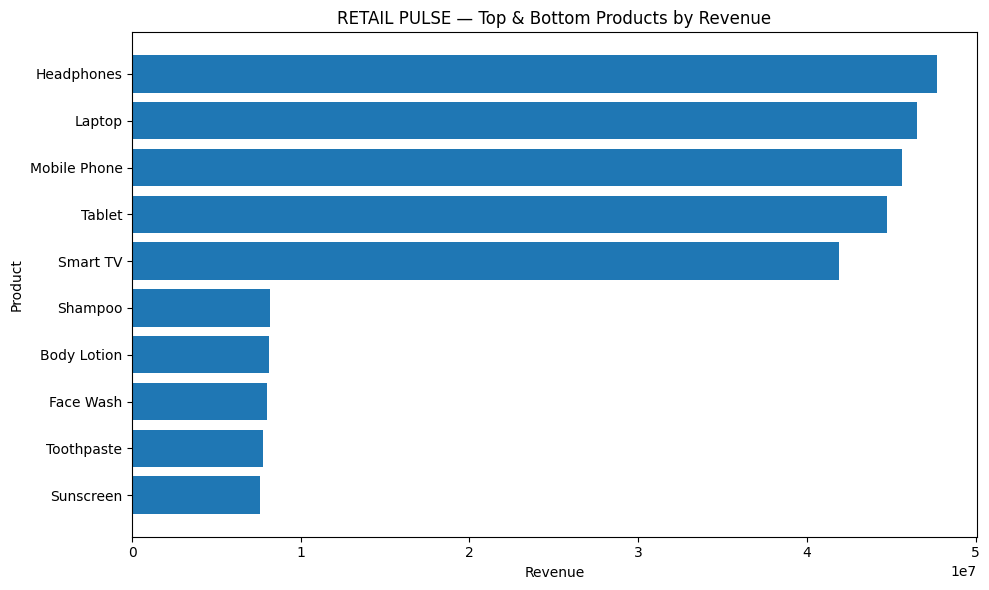

In [29]:
# Task 3 — Top and Bottom Product Revenue

plot_data = top_bottom_products.sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Product"],
    plot_data["Revenue"]
)

plt.title("RETAIL PULSE — Top & Bottom Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [44]:
# Task 3 — Top 2 and Bottom 2 Products for Each Category

category_product_revenue = (
    df.groupby(["category", "product_name"], as_index=False)["revenue"]
      .sum()
)

# Rank products within each category
category_product_revenue["Rank"] = (
    category_product_revenue
    .groupby("category")["revenue"]
    .rank(method="first", ascending=False)
)

# Total number of products in each category
category_product_revenue["Total Products"] = (
    category_product_revenue
    .groupby("category")["product_name"]
    .transform("count")
)

# Select top 2 and bottom 2
top_products = category_product_revenue[
    category_product_revenue["Rank"] <= 2
].copy()

bottom_products = category_product_revenue[
    category_product_revenue["Rank"] >
    category_product_revenue["Total Products"] - 2
].copy()

top_products["Performance"] = "Top 2"
bottom_products["Performance"] = "Bottom 2"

top_bottom_by_category = pd.concat(
    [top_products, bottom_products],
    ignore_index=True
)

top_bottom_by_category = top_bottom_by_category[
    ["category", "product_name", "revenue", "Performance"]
].sort_values(
    ["category", "Performance", "revenue"],
    ascending=[True, True, False]
).reset_index(drop=True)

top_bottom_by_category.style \
    .format({"revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Top 2 & Bottom 2 Products by Category") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,category,product_name,revenue,Performance
0,Apparel,Formal Shirt,"₹13,748,976.91",Bottom 2
1,Apparel,Kurta,"₹13,606,747.03",Bottom 2
2,Apparel,Saree,"₹14,161,864.63",Top 2
3,Apparel,T-Shirt,"₹14,099,251.65",Top 2
4,Electronics,Tablet,"₹44,744,388.93",Bottom 2
5,Electronics,Smart TV,"₹41,882,166.21",Bottom 2
6,Electronics,Headphones,"₹47,696,053.99",Top 2
7,Electronics,Laptop,"₹46,551,078.39",Top 2
8,Grocery,Oil (1L),"₹8,431,630.01",Bottom 2
9,Grocery,Sugar (1kg),"₹8,377,786.05",Bottom 2


In [47]:
# Task 3 — Identify category drag from bottom-performing products

category_summary = (
    top_bottom_by_category
    .groupby(["category", "Performance"])["revenue"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

category_summary["Top 2 Revenue"] = category_summary.get("Top 2", 0)
category_summary["Bottom 2 Revenue"] = category_summary.get("Bottom 2", 0)

category_summary = category_summary[
    ["category", "Top 2 Revenue", "Bottom 2 Revenue"]
]

category_summary.style \
    .format({
        "Top 2 Revenue": "₹{:,.2f}",
        "Bottom 2 Revenue": "₹{:,.2f}"
    }) \
    .set_caption("RETAIL PULSE — Category Top/Bottom Product Contribution")
    
    # Compare the strength of top and bottom products within each category

category_summary["Bottom-to-Top Revenue Ratio"] = (
    category_summary["Bottom 2 Revenue"] /
    category_summary["Top 2 Revenue"]
) * 100

category_summary.style \
    .format({
        "Top 2 Revenue": "₹{:,.2f}",
        "Bottom 2 Revenue": "₹{:,.2f}",
        "Bottom-to-Top Revenue Ratio": "{:.2f}%"
    }) \
    .set_caption("RETAIL PULSE — Category Product Performance Comparison")

Performance,category,Top 2 Revenue,Bottom 2 Revenue,Bottom-to-Top Revenue Ratio
0,Apparel,"₹28,261,116.28","₹27,355,723.94",96.80%
1,Electronics,"₹94,247,132.38","₹86,626,555.14",91.91%
2,Grocery,"₹17,050,475.50","₹16,809,416.06",98.59%
3,Home & Kitchen,"₹33,579,789.89","₹31,968,171.56",95.20%
4,Personal Care,"₹16,274,906.26","₹15,362,675.93",94.39%


In [51]:
# Task 3 — Identify the category with the largest Top 2 vs Bottom 2 gap

category_summary["Performance Gap"] = (
    category_summary["Top 2 Revenue"] -
    category_summary["Bottom 2 Revenue"]
)

supplier_review_table = (
    category_summary
    .sort_values("Performance Gap", ascending=False)
    .reset_index(drop=True)
)

supplier_review_table.style \
    .format({
        "Top 2 Revenue": "₹{:,.2f}",
        "Bottom 2 Revenue": "₹{:,.2f}",
        "Bottom-to-Top Revenue Ratio": "{:.2f}%",
        "Performance Gap": "₹{:,.2f}"
    }) \
    .set_caption("RETAIL PULSE — Supplier Review Category Comparison")


Performance,category,Top 2 Revenue,Bottom 2 Revenue,Bottom-to-Top Revenue Ratio,Performance Gap
0,Electronics,"₹94,247,132.38","₹86,626,555.14",91.91%,"₹7,620,577.24"
1,Home & Kitchen,"₹33,579,789.89","₹31,968,171.56",95.20%,"₹1,611,618.33"
2,Personal Care,"₹16,274,906.26","₹15,362,675.93",94.39%,"₹912,230.33"
3,Apparel,"₹28,261,116.28","₹27,355,723.94",96.80%,"₹905,392.34"
4,Grocery,"₹17,050,475.50","₹16,809,416.06",98.59%,"₹241,059.44"


In [52]:
supplier_review_category = supplier_review_table.iloc[0]["category"]

print(f"Category requiring supplier review: {supplier_review_category}")

Category requiring supplier review: Electronics


## Task 3 — Supplier Review Decision

### Recommended Category for Review

**Electronics** should receive closer attention during the supplier review.

### Why?

Electronics shows the **largest revenue gap between its Top 2 and Bottom 2 products**, with Top 2 products generating **₹94.25 million** compared with **₹86.63 million** from the Bottom 2, resulting in a **₹7.62 million performance gap**.

This indicates a meaningful difference in product contribution within the category and provides a clear area for supplier discussion.

### Recommended Discussion

The Category Manager should investigate the reasons behind the weaker Electronics products, including **demand, pricing, discounting, product positioning, and assortment decisions**.

The objective should be to determine whether these lower-performing products can be **improved, repositioned, replaced, or better supported**.

# Task 4 — Category Revenue & Discount Effectiveness

## Objective

Evaluate overall revenue performance across product categories and examine how different discount levels relate to transaction value and units sold.

## Business Questions

1. Which categories contribute the most and least to total revenue?
2. How does revenue performance differ across categories?
3. How do different discount levels affect average revenue per transaction?
4. Do higher discounts result in a meaningful increase in units sold?
5. What do the observed discount patterns imply for category-level decision making?

## Business Relevance

This analysis helps the Category Manager understand the relative contribution of each category and assess whether higher discounting is associated with improved sales volume or reduced transaction value.

In [34]:
# Task 4 — Category Revenue Performance

category_revenue = (
    df.groupby("category", as_index=False)["revenue"]
      .sum()
      .sort_values("revenue", ascending=False)
      .reset_index(drop=True)
)

category_revenue.index = category_revenue.index + 1

category_revenue.columns = ["Category", "Total Revenue"]

category_revenue.style \
    .format({"Total Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Category Revenue Performance") \
    .set_properties(**{
        "text-align": "left",
        "font-size": "12pt"
    }) \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])

,Category,Total Revenue
1,Electronics,"₹226,527,724.93"
2,Home & Kitchen,"₹81,845,721.33"
3,Apparel,"₹69,479,589.68"
4,Grocery,"₹42,302,580.76"
5,Personal Care,"₹39,648,560.08"


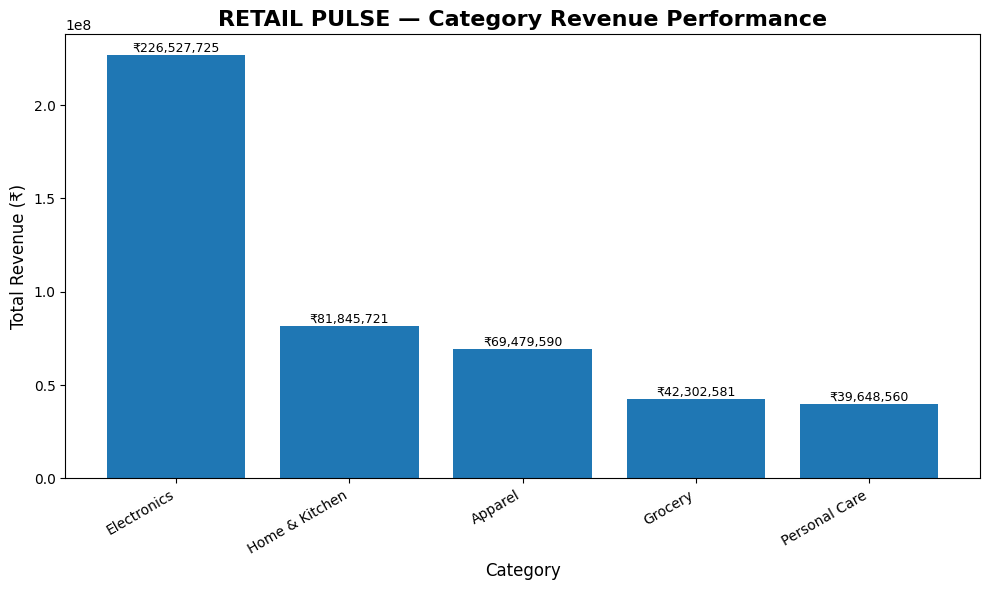

In [35]:
# Task 4 — Category Revenue Comparison

plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_revenue["Category"],
    category_revenue["Total Revenue"]
)

plt.title(
    "RETAIL PULSE — Category Revenue Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Revenue (₹)", fontsize=12)

plt.xticks(rotation=30, ha="right")

# Add revenue labels above bars
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [46]:
# Task 4 — Discount Effectiveness

def discount_bracket(x):
    if x == 0:
        return "0%"
    elif x == 5:
        return "5%"
    elif x == 10:
        return "10%"
    elif x == 15:
        return "15%"
    elif x == 20:
        return "20%"
    else:
        return "25%+"


df["discount_bracket"] = df["discount_pct"].apply(discount_bracket)

discount_analysis = (
    df.groupby("discount_bracket", as_index=False)
      .agg(
          Average_Revenue_Per_Transaction=("revenue", "mean"),
          Average_Units_Sold=("units_sold", "mean"),
          Transactions=("transaction_id", "count")
      )
)

discount_order = ["0%", "5%", "10%", "15%", "20%", "25%+"]

discount_analysis["discount_bracket"] = pd.Categorical(
    discount_analysis["discount_bracket"],
    categories=discount_order,
    ordered=True
)

discount_analysis = (
    discount_analysis
    .sort_values("discount_bracket")
    .reset_index(drop=True)
)

discount_analysis.style \
    .format({
        "Average_Revenue_Per_Transaction": "₹{:,.2f}",
        "Average_Units_Sold": "{:.2f}",
        "Transactions": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Discount Effectiveness") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,discount_bracket,Average_Revenue_Per_Transaction,Average_Units_Sold,Transactions
0,0%,"₹4,685.65",2.59,"36,033"
1,5%,"₹4,303.73",2.59,"23,922"
2,10%,"₹4,005.55",2.57,"23,810"
3,15%,"₹4,069.16",2.60,"11,935"
4,20%,"₹3,631.73",2.58,"12,136"


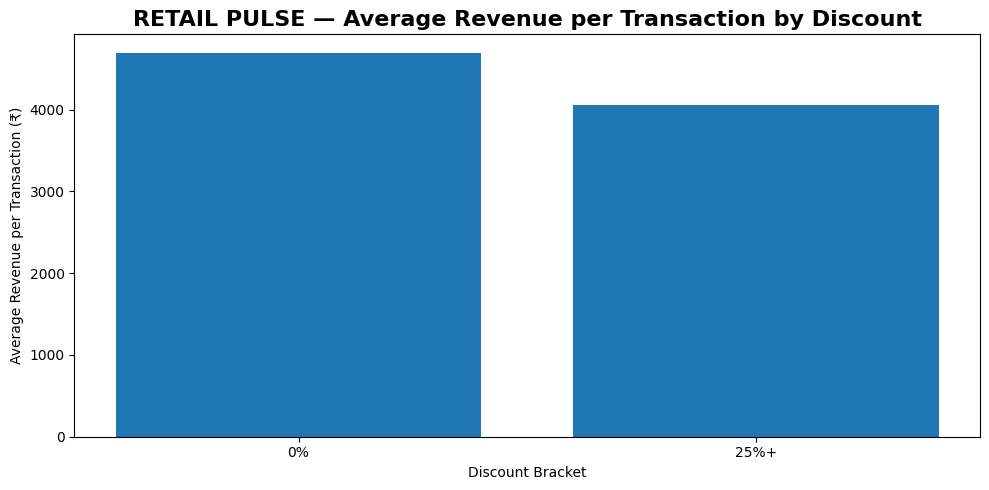

In [7]:
# Task 4 — Discount Effectiveness Chart

plt.figure(figsize=(10, 5))

plt.bar(
    discount_analysis["discount_bracket"].astype(str),
    discount_analysis["Average_Revenue_Per_Transaction"]
)

plt.title(
    "RETAIL PULSE — Average Revenue per Transaction by Discount",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Discount Bracket")
plt.ylabel("Average Revenue per Transaction (₹)")

plt.tight_layout()
plt.show()

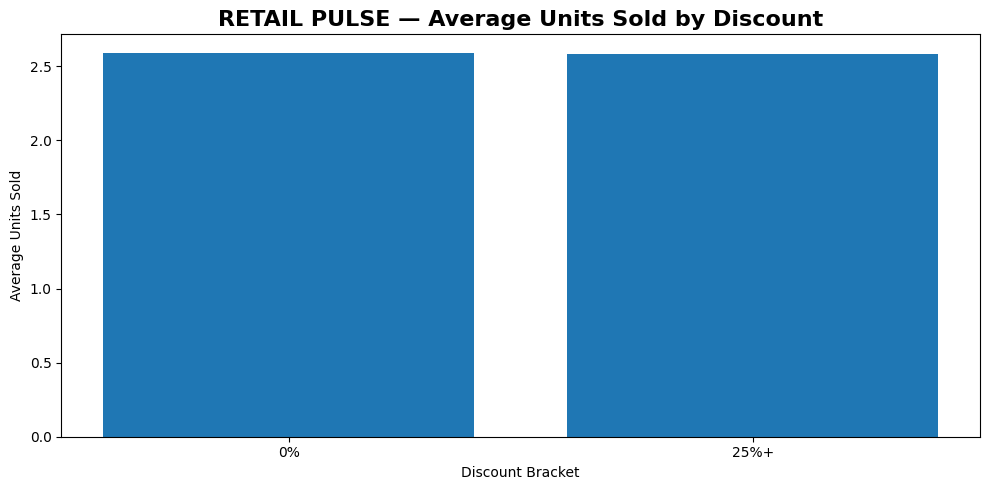

In [8]:
# Task 4 — Average Units Sold by Discount

plt.figure(figsize=(10, 5))

plt.bar(
    discount_analysis["discount_bracket"].astype(str),
    discount_analysis["Average_Units_Sold"]
)

plt.title(
    "RETAIL PULSE — Average Units Sold by Discount",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Discount Bracket")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

## Task 4 — Business Insight

### Category Revenue Performance

**Electronics** is the highest revenue-contributing category, generating **₹226.53 million**, while **Personal Care** contributes the lowest category revenue at **₹39.65 million**. This highlights Electronics as the dominant revenue category and Personal Care as the smallest contributor.

### Discount Effectiveness

The dataset contains two observed discount levels: **0% and 25%+**. Transactions with no discount generated a higher average revenue per transaction of **₹4,685.65**, compared with **₹4,052.28** for transactions receiving 25%+ discount.

Average units sold were almost identical at **2.59 units** for 0% discount and **2.58 units** for 25%+ discount.

### Category Manager Implication

The observed data does not show a meaningful increase in units sold at the higher discount level, while average revenue per transaction is lower. Therefore, **higher discounting may reduce transaction value without providing a meaningful volume benefit**. The Category Manager should review whether 25%+ discounting is justified and consider using discounts selectively rather than assuming deeper discounts will increase sales volume.

# Task 5 — Time-Based Sales Patterns

## Objective

Analyse sales patterns across days of the week and months to identify high- and low-performing periods and understand when the selected category contributes most strongly to revenue.

## Business Questions

1. Which days of the week generate the highest and lowest revenue?
2. Which months show the highest and lowest overall revenue?
3. What time-based patterns are observed for the Electronics category?
4. How can these patterns support sales, inventory, and promotional planning?

In [64]:
# Task 5 — Identify the most interesting category

category_summary.sort_values(
    "Total_Revenue",
    ascending=False
).style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}",
        "Units_Sold": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Category Performance for Task 5")

,category,Total_Revenue,Transactions,Units_Sold
0,Electronics,"₹226,527,724.93","4,015","10,372"
1,Home & Kitchen,"₹81,845,721.33","8,388","21,658"
2,Apparel,"₹69,479,589.68","15,301","39,456"
3,Grocery,"₹42,302,580.76","54,185","140,326"
4,Personal Care,"₹39,648,560.08","25,947","66,781"


In [36]:
# Task 5 — Prepare time-based features

df["day_of_week"] = df["date"].dt.day_name()
df["month_name"] = df["date"].dt.month_name()

print("Time-based features created successfully.")

Time-based features created successfully.


In [37]:
# Revenue by day of week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_revenue = (
    df.groupby("day_of_week")["revenue"]
      .sum()
      .reindex(day_order)
      .reset_index()
)

day_revenue.columns = ["Day", "Total Revenue"]

day_revenue.style \
    .format({"Total Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Revenue by Day of Week") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Day,Total Revenue
0,Monday,"₹52,315,665.05"
1,Tuesday,"₹53,407,372.28"
2,Wednesday,"₹55,702,931.10"
3,Thursday,"₹58,382,818.55"
4,Friday,"₹68,213,909.13"
5,Saturday,"₹91,613,741.57"
6,Sunday,"₹80,167,739.10"


In [38]:
# Revenue by month

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June"
]

month_revenue = (
    df.groupby("month_name")["revenue"]
      .sum()
      .reindex(month_order)
      .reset_index()
)

month_revenue.columns = ["Month", "Total Revenue"]

month_revenue.style \
    .format({"Total Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Revenue by Month") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Month,Total Revenue
0,January,"₹84,768,131.10"
1,February,"₹73,833,666.23"
2,March,"₹80,689,884.84"
3,April,"₹75,670,487.12"
4,May,"₹75,559,873.38"
5,June,"₹69,282,134.11"


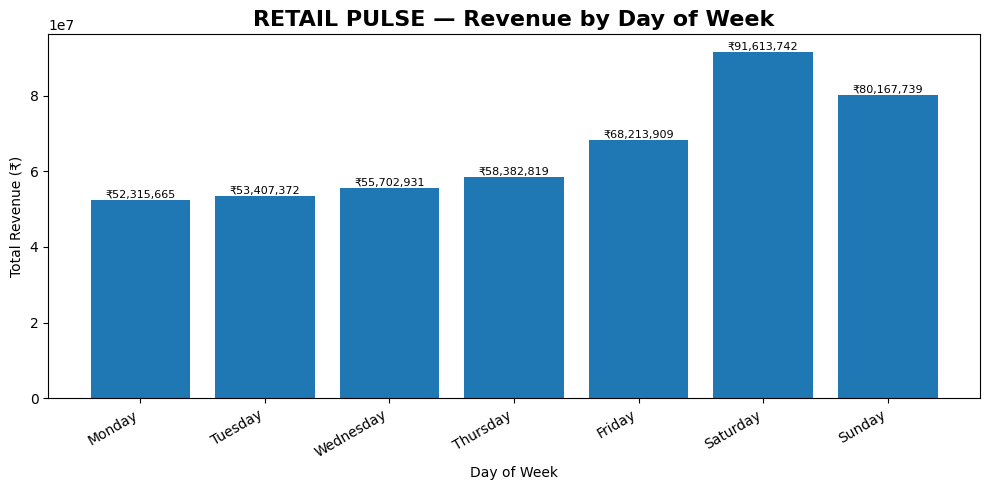

In [39]:
# Revenue pattern by day of week

plt.figure(figsize=(10, 5))

bars = plt.bar(
    day_revenue["Day"],
    day_revenue["Total Revenue"]
)

plt.title(
    "RETAIL PULSE — Revenue by Day of Week",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day of Week")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=30, ha="right")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

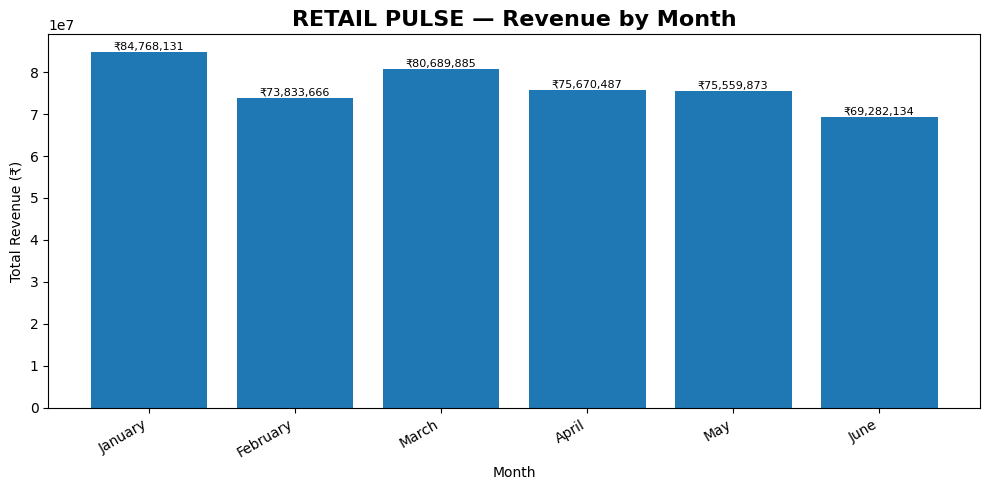

In [63]:
# Revenue pattern by month

plt.figure(figsize=(10, 5))

bars = plt.bar(
    month_revenue["Month"],
    month_revenue["Total Revenue"]
)

plt.title(
    "RETAIL PULSE — Revenue by Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=30, ha="right")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [61]:
# Task 5 — Average Daily Revenue by Day of Week

daily_revenue = (
    df.groupby(["date", "day_of_week"], as_index=False)["revenue"]
      .sum()
)

day_pattern = (
    daily_revenue
    .groupby("day_of_week", as_index=False)["revenue"]
    .mean()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_pattern["day_of_week"] = pd.Categorical(
    day_pattern["day_of_week"],
    categories=day_order,
    ordered=True
)

day_pattern = (
    day_pattern
    .sort_values("day_of_week")
    .reset_index(drop=True)
)

day_pattern.columns = [
    "Day of Week",
    "Average Daily Revenue"
]

day_pattern.style \
    .format({"Average Daily Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Average Daily Revenue by Day") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Day of Week,Average Daily Revenue
0,Monday,"₹2,012,140.96"
1,Tuesday,"₹2,054,129.70"
2,Wednesday,"₹2,228,117.24"
3,Thursday,"₹2,245,493.02"
4,Friday,"₹2,623,611.89"
5,Saturday,"₹3,523,605.44"
6,Sunday,"₹3,083,374.58"


In [65]:
# Task 5 — Electronics Category Time Pattern

electronics_df = df[df["category"] == "Electronics"].copy()

# Daily revenue
electronics_daily_revenue = (
    electronics_df
    .groupby(["date", "day_of_week"], as_index=False)["revenue"]
    .sum()
)

# Average daily revenue by day of week
electronics_day_pattern = (
    electronics_daily_revenue
    .groupby("day_of_week", as_index=False)["revenue"]
    .mean()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

electronics_day_pattern["day_of_week"] = pd.Categorical(
    electronics_day_pattern["day_of_week"],
    categories=day_order,
    ordered=True
)

electronics_day_pattern = (
    electronics_day_pattern
    .sort_values("day_of_week")
    .reset_index(drop=True)
)

electronics_day_pattern.columns = [
    "Day of Week",
    "Average Daily Revenue"
]

electronics_day_pattern.style \
    .format({"Average Daily Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Electronics Average Daily Revenue") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Day of Week,Average Daily Revenue
0,Monday,"₹970,975.52"
1,Tuesday,"₹975,432.75"
2,Wednesday,"₹1,111,579.33"
3,Thursday,"₹1,061,517.79"
4,Friday,"₹1,291,063.65"
5,Saturday,"₹1,786,658.45"
6,Sunday,"₹1,558,130.36"


In [66]:
# Task 5 — Electronics Total Revenue by Month

electronics_month_pattern = (
    electronics_df
    .groupby("month", as_index=False)["revenue"]
    .sum()
    .sort_values("month")
    .reset_index(drop=True)
)

electronics_month_pattern.columns = [
    "Month",
    "Total Revenue"
]

electronics_month_pattern.style \
    .format({"Total Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Electronics Monthly Revenue") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Month,Total Revenue
0,2026-01,"₹45,686,596.63"
1,2026-02,"₹38,988,602.50"
2,2026-03,"₹40,846,509.47"
3,2026-04,"₹37,092,265.09"
4,2026-05,"₹34,226,926.43"
5,2026-06,"₹29,686,824.81"


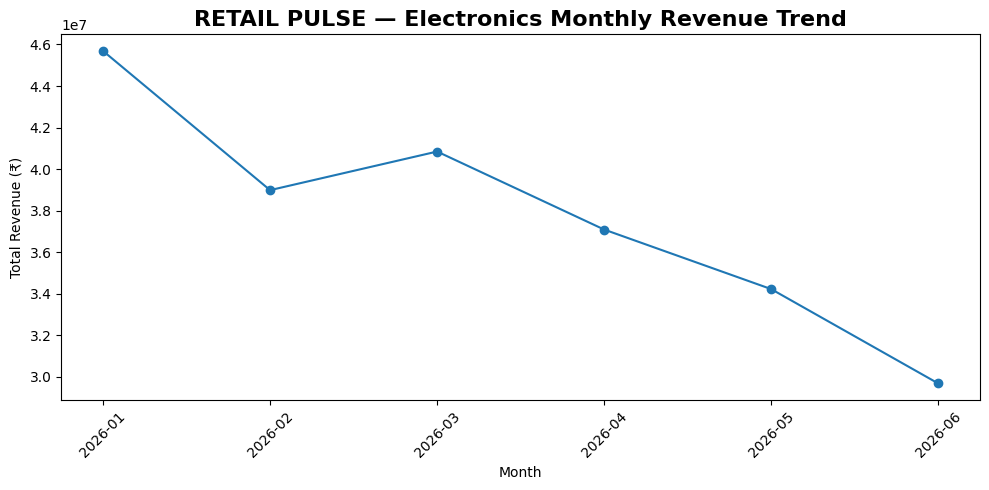

In [68]:
# Electronics Monthly Revenue Trend

plt.figure(figsize=(10, 5))

plt.plot(
    electronics_month_pattern["Month"].astype(str),
    electronics_month_pattern["Total Revenue"],
    marker="o"
)

plt.title(
    "RETAIL PULSE — Electronics Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
# Task 5 — Key Time-Based Insights

best_day = day_pattern.loc[
    day_pattern["Average Daily Revenue"].idxmax()
]

worst_day = day_pattern.loc[
    day_pattern["Average Daily Revenue"].idxmin()
]

best_month = month_pattern.loc[
    month_pattern["Total Revenue"].idxmax()
]

worst_month = month_pattern.loc[
    month_pattern["Total Revenue"].idxmin()
]

electronics_best_day = electronics_day_pattern.loc[
    electronics_day_pattern["Average Daily Revenue"].idxmax()
]

electronics_worst_day = electronics_day_pattern.loc[
    electronics_day_pattern["Average Daily Revenue"].idxmin()
]

electronics_best_month = electronics_month_pattern.loc[
    electronics_month_pattern["Total Revenue"].idxmax()
]

electronics_worst_month = electronics_month_pattern.loc[
    electronics_month_pattern["Total Revenue"].idxmin()
]

print("========== RETAIL PULSE — TASK 5 KEY INSIGHTS ==========")

print(f"Overall best day       : {best_day['Day of Week']}")
print(f"Overall worst day      : {worst_day['Day of Week']}")

print(f"Overall best month     : {best_month['Month']}")
print(f"Overall worst month    : {worst_month['Month']}")

print()
print("---------- ELECTRONICS ----------")

print(f"Best Electronics day   : {electronics_best_day['Day of Week']}")
print(f"Worst Electronics day  : {electronics_worst_day['Day of Week']}")

print(f"Best Electronics month : {electronics_best_month['Month']}")
print(f"Worst Electronics month: {electronics_worst_month['Month']}")

print("==========================================================")

========== RETAIL PULSE — TASK 5 KEY INSIGHTS ==========
Overall best day       : Saturday
Overall worst day      : Monday
Overall best month     : 2026-01
Overall worst month    : 2026-06

---------- ELECTRONICS ----------
Best Electronics day   : Saturday
Worst Electronics day  : Monday
Best Electronics month : 2026-01
Worst Electronics month: 2026-06


## Task 5 — Business Insight

### Overall Time Pattern

**Saturday** is the strongest day based on average daily revenue at approximately **₹3.52 million**, while **Monday** is the weakest at approximately **₹2.01 million**. This indicates a clear difference in revenue performance across the week.

At the monthly level, **January** records the highest overall revenue at approximately **₹84.77 million**, while **June** records the lowest at approximately **₹69.28 million**.

### Electronics Time Pattern

Electronics follows a similar weekly pattern, with **Saturday** generating the highest average daily revenue at approximately **₹1.79 million** and **Monday** the lowest at approximately **₹0.97 million**.

Electronics also shows a declining monthly pattern after January, falling from **₹45.69 million in January to ₹29.69 million in June**. This is consistent with the category's declining trend identified in Task 2.

### Category Manager Implication

The Category Manager can use the stronger **weekend revenue pattern** to support inventory availability, staffing, and promotional planning. The weaker Monday performance can be investigated for improvement opportunities.

For Electronics, the continued monthly decline should receive particular attention, while high-performing periods such as Saturdays can be used to optimize product availability and promotional timing.

# Task 6 — Category Manager Briefing

## Objective

Consolidate the key findings from the previous analyses into a concise Category Manager briefing and identify the main business priorities, opportunities, and areas requiring further investigation.

## Business Questions

1. Which category and products are the major revenue drivers?
2. Which categories or products require management attention?
3. What do the discount and time-based sales patterns imply for business decisions?
4. What additional information would be required before making a final investment or supplier recommendation?

## Business Relevance

This briefing brings together the findings from category, product, discount, and time-based analyses to support practical Category Manager decisions while clearly identifying the limitations of revenue-only analysis.

In [57]:
# Task 6 — Monthly Revenue Trend

monthly_revenue = (
    df.groupby("month", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("revenue", "count")
      )
      .sort_values("month")
      .reset_index(drop=True)
)

monthly_revenue.style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Monthly Revenue Trend") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
                ("text-align", "right")
            ]
        }
    ])

,month,Total_Revenue,Transactions
0,2026-01,"₹84,768,131.10","18,251"
1,2026-02,"₹73,833,666.23","16,475"
2,2026-03,"₹80,689,884.84","18,159"
3,2026-04,"₹75,670,487.12","17,805"
4,2026-05,"₹75,559,873.38","18,904"
5,2026-06,"₹69,282,134.11","18,242"


## Task 6 — Monthly Revenue Insight

Overall monthly revenue shows a fluctuating but declining pattern across the analysis period. **January recorded the highest revenue at ₹84.77 million**, while **June recorded the lowest at ₹69.28 million**.

Revenue increased from February to March but declined again from March through June. This indicates that overall sales performance weakened toward the end of the analysis period and should be considered alongside the category-level decline identified earlier.

The Category Manager should investigate the reasons behind the decline toward June, particularly for Electronics, while considering seasonal demand, product performance, pricing, and promotional activity before taking corrective action.

# Task 7 — Category Performance

## Objective

Evaluate the overall performance of each product category using total revenue, transaction volume, and units sold to understand the relative contribution and scale of each category.

## Business Questions

1. Which category generates the highest total revenue?
2. Which category has the highest transaction volume?
3. Which category sells the highest number of units?
4. Are high transaction and unit volumes translating into high revenue?
5. What do these differences imply for Category Manager decision-making?

## Business Relevance

This analysis helps distinguish between categories that generate high revenue and categories that generate high sales volume. Comparing revenue, transactions, and units sold provides a broader view of category performance and helps identify categories that may require further investigation.

In [8]:
# Task 7 — Category Performance

category_summary = (
    df.groupby("category", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("revenue", "count"),
          Units_Sold=("units_sold", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index(drop=True)
)

# Revenue efficiency metrics
category_summary["Revenue_Per_Transaction"] = (
    category_summary["Total_Revenue"] /
    category_summary["Transactions"]
)

category_summary["Revenue_Per_Unit"] = (
    category_summary["Total_Revenue"] /
    category_summary["Units_Sold"]
)

# Display formatted table
category_summary.style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}",
        "Units_Sold": "{:,}",
        "Revenue_Per_Transaction": "₹{:,.2f}",
        "Revenue_Per_Unit": "₹{:,.2f}"
    }) \
    .set_caption("RETAIL PULSE — Category Performance & Revenue Efficiency") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
                ("text-align", "right")
            ]
        }
    ])

,category,Total_Revenue,Transactions,Units_Sold,Revenue_Per_Transaction,Revenue_Per_Unit
0,Electronics,"₹226,527,724.93","4,015","10,372","₹56,420.35","₹21,840.31"
1,Home & Kitchen,"₹81,845,721.33","8,388","21,658","₹9,757.48","₹3,779.01"
2,Apparel,"₹69,479,589.68","15,301","39,456","₹4,540.85","₹1,760.94"
3,Grocery,"₹42,302,580.76","54,185","140,326",₹780.71,₹301.46
4,Personal Care,"₹39,648,560.08","25,947","66,781","₹1,528.06",₹593.71


## Task 7 — Business Insight

### Revenue Leadership

**Electronics** is the highest revenue-generating category, contributing **₹226.53 million** from only **4,015 transactions** and **10,372 units sold**.

### Volume Leadership

**Grocery** has the highest transaction volume with **54,185 transactions** and the highest units sold with **140,326 units**, yet generates only **₹42.30 million** in revenue.

### Key Business Observation

The category with the highest sales volume is not the category with the highest revenue. Electronics generates substantially higher revenue from far fewer transactions and units, indicating a much higher revenue contribution per transaction and per unit.

### Category Manager Implication

The Category Manager should evaluate categories using both **revenue and sales volume**, rather than relying on transaction or unit volume alone. Electronics should be examined for its strong value contribution, while Grocery's high volume but comparatively lower revenue warrants further investigation into pricing, product mix, and unit economics.

# Task 8 — Day-of-Week Performance

## Objective

Analyse retail performance across different days of the week using revenue, transaction volume, and units sold to identify the strongest and weakest sales periods.

## Business Questions

1. Which day of the week generates the highest revenue?
2. Which day generates the lowest revenue?
3. Do transaction and unit volumes follow the same pattern as revenue?
4. What do the day-of-week patterns imply for promotional, inventory, and operational planning?

## Business Relevance

Understanding weekly sales patterns helps the Category Manager align inventory availability, staffing, and promotional activity with periods of stronger or weaker customer demand.

In [59]:
# Task 8 — Day-of-Week Performance

day_summary = (
    df.groupby("day_of_week", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("revenue", "count"),
          Units_Sold=("units_sold", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index(drop=True)
)

day_summary.style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}",
        "Units_Sold": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Day-of-Week Performance") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
                ("text-align", "right")
            ]
        }
    ])

,day_of_week,Total_Revenue,Transactions,Units_Sold
0,Saturday,"₹91,613,741.57","20,727","53,446"
1,Sunday,"₹80,167,739.10","18,420","47,691"
2,Friday,"₹68,213,909.13","16,028","41,526"
3,Thursday,"₹58,382,818.55","13,720","35,462"
4,Wednesday,"₹55,702,931.10","12,985","33,497"
5,Tuesday,"₹53,407,372.28","13,293","34,093"
6,Monday,"₹52,315,665.05","12,663","32,878"


## Task 8 — Business Insight

### Day-of-Week Performance

**Saturday** is the strongest revenue day, generating **₹91.61 million**, while **Monday** is the weakest at **₹52.32 million**.

Saturday also records the highest transaction volume and units sold, indicating that its revenue leadership is supported by stronger sales activity rather than revenue alone.

### Category Manager Implication

The stronger Saturday performance presents an opportunity to align inventory availability, staffing, and promotional activity with higher-demand periods.

The lower Monday performance can be monitored to determine whether targeted promotions or other operational interventions could improve sales activity.

# Task 9 — Product Performance

## Objective

Analyse product-level revenue and sales volume to identify the strongest and weakest products and understand their contribution to overall retail performance.

## Business Questions

1. Which products generate the highest revenue?
2. Which products generate the lowest revenue?
3. How do product sales volumes compare with their revenue contribution?
4. Which products should receive attention from the Category Manager?

## Business Relevance

Product-level analysis helps the Category Manager identify key revenue drivers and underperforming products that may require changes in pricing, promotion, inventory allocation, or supplier strategy.

In [9]:
# Task 9 — Product Performance

product_summary = (
    df.groupby("product_name", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("revenue", "count"),
          Units_Sold=("units_sold", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index(drop=True)
)

product_summary["Revenue_Per_Transaction"] = (
    product_summary["Total_Revenue"] /
    product_summary["Transactions"]
)

product_summary["Revenue_Per_Unit"] = (
    product_summary["Total_Revenue"] /
    product_summary["Units_Sold"]
)

product_summary.style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}",
        "Units_Sold": "{:,}",
        "Revenue_Per_Transaction": "₹{:,.2f}",
        "Revenue_Per_Unit": "₹{:,.2f}"
    }) \
    .set_caption("RETAIL PULSE — Product Performance") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
                ("text-align", "right")
            ]
        }
    ])

,product_name,Total_Revenue,Transactions,Units_Sold,Revenue_Per_Transaction,Revenue_Per_Unit
0,Headphones,"₹47,696,053.99",790,"2,096","₹60,374.75","₹22,755.75"
1,Laptop,"₹46,551,078.39",837,"2,153","₹55,616.58","₹21,621.49"
2,Mobile Phone,"₹45,654,037.41",796,"2,077","₹57,354.32","₹21,980.76"
3,Tablet,"₹44,744,388.93",820,"2,069","₹54,566.33","₹21,626.09"
4,Smart TV,"₹41,882,166.21",772,"1,977","₹54,251.51","₹21,184.71"
5,Mixer Grinder,"₹16,903,254.58","1,715","4,414","₹9,856.13","₹3,829.46"
6,Storage Box,"₹16,676,535.31","1,699","4,443","₹9,815.50","₹3,753.44"
7,Dinner Set,"₹16,297,759.88","1,667","4,281","₹9,776.70","₹3,807.00"
8,Pressure Cooker,"₹16,142,329.39","1,632","4,253","₹9,891.13","₹3,795.52"
9,Water Bottle,"₹15,825,842.17","1,675","4,267","₹9,448.26","₹3,708.89"


In [10]:
# Task 9 — Top and Bottom Products

top_5_products = product_summary.head(5).copy()
bottom_5_products = product_summary.tail(5).copy()

print("========== TOP 5 PRODUCTS ==========")
display(top_5_products)

print("\n========== BOTTOM 5 PRODUCTS ==========")
display(bottom_5_products)

========== TOP 5 PRODUCTS ==========


,product_name,Total_Revenue,Transactions,Units_Sold,Revenue_Per_Transaction,Revenue_Per_Unit
0,Headphones,47696053.99,790,2096,60374.751886,22755.750949
1,Laptop,46551078.39,837,2153,55616.581111,21621.494840
2,Mobile Phone,45654037.41,796,2077,57354.318354,21980.759466
3,Tablet,44744388.93,820,2069,54566.327963,21626.094215
4,Smart TV,41882166.21,772,1977,54251.510635,21184.707238



========== BOTTOM 5 PRODUCTS ==========


,product_name,Total_Revenue,Transactions,Units_Sold,Revenue_Per_Transaction,Revenue_Per_Unit
20,Shampoo,8168328.26,5276,13660,1548.204750,597.974250
21,Body Lotion,8106578.00,5271,13617,1537.958262,595.327752
22,Face Wash,8010977.89,5173,13385,1548.613549,598.504138
23,Toothpaste,7768812.48,5178,13292,1500.350035,584.472802
24,Sunscreen,7593863.45,5049,12827,1504.033165,592.021786


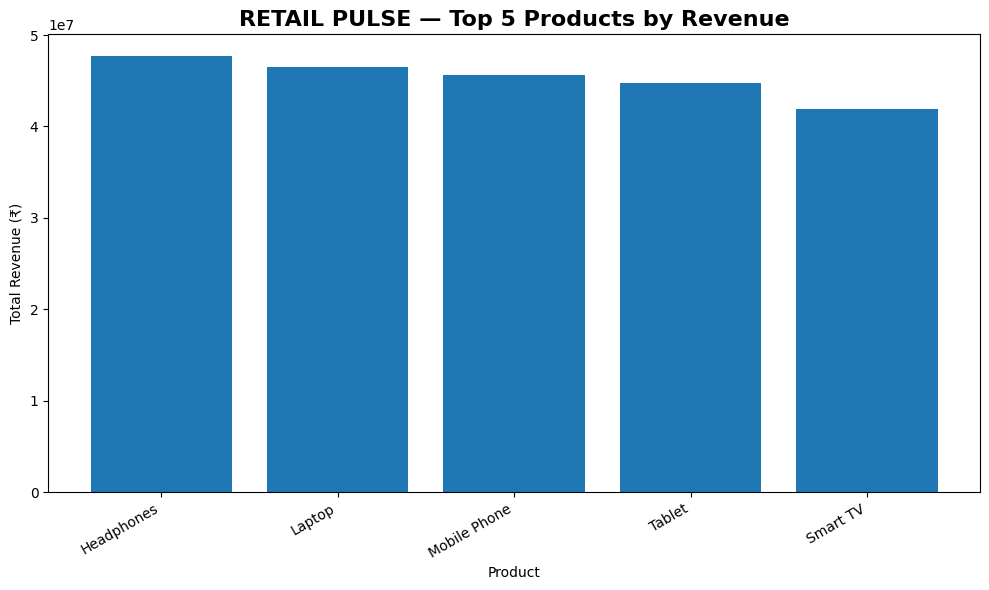

In [11]:
# Task 9 — Top 5 Product Revenue

plt.figure(figsize=(10, 6))

plt.bar(
    top_5_products["product_name"],
    top_5_products["Total_Revenue"]
)

plt.title(
    "RETAIL PULSE — Top 5 Products by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [12]:
# Task 9 — Top 5 vs Bottom 5 Revenue Comparison

top_5_revenue = top_5_products["Total_Revenue"].sum()
bottom_5_revenue = bottom_5_products["Total_Revenue"].sum()

revenue_gap = top_5_revenue - bottom_5_revenue
bottom_to_top_ratio = (bottom_5_revenue / top_5_revenue) * 100

product_comparison = pd.DataFrame({
    "Metric": [
        "Top 5 Products Revenue",
        "Bottom 5 Products Revenue",
        "Revenue Gap",
        "Bottom-to-Top Revenue Ratio"
    ],
    "Value": [
        top_5_revenue,
        bottom_5_revenue,
        revenue_gap,
        bottom_to_top_ratio
    ]
})

product_comparison.style \
    .format({
        "Value": lambda x: f"₹{x:,.2f}"
    }) \
    .set_caption("RETAIL PULSE — Top 5 vs Bottom 5 Product Revenue") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Metric,Value
0,Top 5 Products Revenue,"₹226,527,724.93"
1,Bottom 5 Products Revenue,"₹39,648,560.08"
2,Revenue Gap,"₹186,879,164.85"
3,Bottom-to-Top Revenue Ratio,₹17.50


## Task 9 — Business Insight

### Top Revenue Drivers

The top-performing products contribute the strongest product-level revenue and represent important revenue drivers for the business. These products should be monitored closely for availability, demand, and continued sales performance.

### Lowest Revenue Contributors

The bottom-performing products generate comparatively lower revenue and may require further investigation. The Category Manager should assess whether their performance is influenced by lower demand, pricing, discounting, product positioning, or inventory availability.

### Category Manager Implication

The strongest products should be protected through appropriate inventory and supplier planning, while lower-performing products should be reviewed for improvement opportunities.

Product-level findings should be considered together with the category, discount, and time-based analysis before making final supplier or investment decisions.

# Task 10 — Store Performance

## Objective

Analyse revenue performance across stores to identify the strongest and weakest store locations and understand differences in transaction activity and sales volume.

## Business Questions

1. Which stores generate the highest and lowest revenue?
2. How do transaction volumes differ across stores?
3. Do higher transaction volumes correspond to higher revenue?
4. Which store locations may require further attention from the Category Manager?

## Business Relevance

Store-level analysis helps identify high-performing locations and stores with comparatively lower sales activity. These findings can support decisions related to inventory allocation, promotional planning, store-level execution, and supplier strategy.

In [13]:
# Task 10 — Store Performance

store_summary = (
    df.groupby("store_city", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("transaction_id", "count"),
          Units_Sold=("units_sold", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index(drop=True)
)

store_summary.style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}",
        "Units_Sold": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Store Performance") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
                ("text-align", "right")
            ]
        }
    ])

,store_city,Total_Revenue,Transactions,Units_Sold
0,Vijayawada,"₹101,125,349.71","23,083","59,993"
1,Guntur,"₹94,554,959.16","21,742","56,134"
2,Tirupati,"₹83,570,220.68","19,949","51,328"
3,Rajahmundry,"₹70,127,187.52","16,478","42,376"
4,Nellore,"₹55,669,840.14","13,883","35,897"
5,Kakinada,"₹54,756,619.57","12,701","32,865"


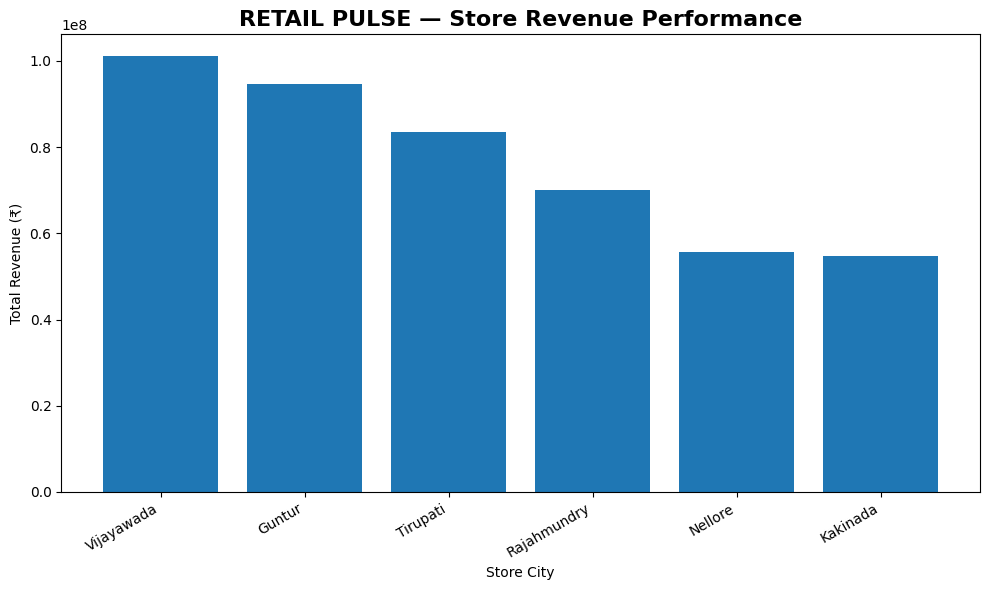

In [14]:
# Task 10 — Store Revenue Comparison

plt.figure(figsize=(10, 6))

plt.bar(
    store_summary["store_city"],
    store_summary["Total_Revenue"]
)

plt.title(
    "RETAIL PULSE — Store Revenue Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Store City")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [15]:
# Task 10 — Identify strongest and weakest stores

highest_revenue_store = store_summary.iloc[0]["store_city"]
lowest_revenue_store = store_summary.iloc[-1]["store_city"]

print(f"Highest revenue store : {highest_revenue_store}")
print(f"Lowest revenue store  : {lowest_revenue_store}")

Highest revenue store : Vijayawada
Lowest revenue store  : Kakinada


## Task 10 — Business Insight

### Highest Revenue Store

The highest-revenue store represents the strongest-performing location in the dataset. Its performance should be examined to understand whether higher transaction activity, stronger product demand, category mix, or other factors are contributing to its results.

### Lowest Revenue Store

The lowest-revenue store generates comparatively lower revenue and should be reviewed for potential performance gaps. The Category Manager can investigate transaction activity, units sold, category mix, and product performance at this location.

### Category Manager Implication

High-performing stores can provide useful benchmarks for store-level execution, inventory availability, and promotional planning. Lower-performing stores should be investigated further before deciding on targeted interventions.

Store-level findings should be considered alongside category, product, discount, and day-of-week performance before making final recommendations.

# Task 11 — Store-Category Performance

## Objective

Analyse revenue performance across stores and product categories to identify which category-store combinations are the strongest and weakest contributors to revenue.

## Business Questions

1. Which categories generate the most revenue within each store?
2. Which store-category combinations are the strongest revenue contributors?
3. Are some categories consistently strong or weak across different stores?
4. Where should the Category Manager focus further investigation?

## Business Relevance

Combining store and category performance provides a more detailed view of revenue drivers. This can help the Category Manager identify location-specific opportunities for inventory allocation, promotions, and supplier planning.

In [16]:
# Task 11 — Store-Category Revenue

store_category_revenue = (
    df.groupby(["store_city", "category"], as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("transaction_id", "count"),
          Units_Sold=("units_sold", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index(drop=True)
)

store_category_revenue.head(15)

,store_city,category,Total_Revenue,Transactions,Units_Sold
0,Vijayawada,Electronics,50084607.85,875,2298
1,Guntur,Electronics,47094146.01,825,2179
2,Tirupati,Electronics,40520370.72,742,1870
3,Rajahmundry,Electronics,34960898.90,601,1543
4,Kakinada,Electronics,27920227.63,464,1257
5,Nellore,Electronics,25947473.82,508,1225
6,Vijayawada,Home & Kitchen,18138015.07,1857,4841
7,Guntur,Home & Kitchen,16867421.49,1733,4475
8,Vijayawada,Apparel,15412651.10,3308,8715
9,Tirupati,Home & Kitchen,15087172.77,1603,4059


In [17]:
# Task 11 — Store-Category Revenue Matrix

store_category_table = (
    store_category_revenue
    .pivot(
        index="store_city",
        columns="category",
        values="Total_Revenue"
    )
    .fillna(0)
)

store_category_table

category,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
store_city,,,,,
Guntur,14076711.12,47094146.01,8424163.88,16867421.49,8092516.66
Kakinada,8024726.90,27920227.63,5019577.44,9212695.33,4579392.27
Nellore,8804632.30,25947473.82,5572379.69,10166819.34,5178534.99
Rajahmundry,10318743.78,34960898.90,6516689.28,12373597.33,5957258.23
Tirupati,12842124.48,40520370.72,7789626.29,15087172.77,7330926.42
Vijayawada,15412651.10,50084607.85,8980144.18,18138015.07,8509931.51


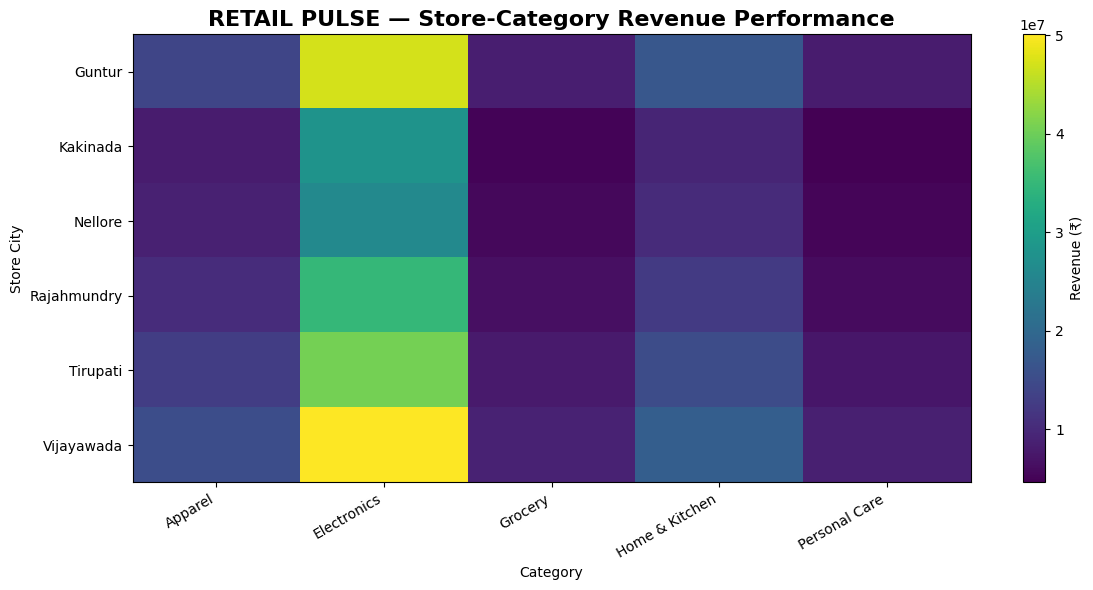

In [18]:
# Task 11 — Store-Category Revenue Heatmap

plt.figure(figsize=(12, 6))

plt.imshow(store_category_table, aspect="auto")

plt.title(
    "RETAIL PULSE — Store-Category Revenue Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Store City")

plt.xticks(
    range(len(store_category_table.columns)),
    store_category_table.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(store_category_table.index)),
    store_category_table.index
)

plt.colorbar(label="Revenue (₹)")

plt.tight_layout()
plt.show()

In [19]:
# Task 11 — Strongest Store-Category Combination

strongest_combination = store_category_revenue.iloc[0]

print("Strongest Store-Category Combination")
print("--------------------------------------")
print(f"Store     : {strongest_combination['store_city']}")
print(f"Category  : {strongest_combination['category']}")
print(f"Revenue   : ₹{strongest_combination['Total_Revenue']:,.2f}")

Strongest Store-Category Combination
--------------------------------------
Store     : Vijayawada
Category  : Electronics
Revenue   : ₹50,084,607.85


## Task 11 — Business Insight

### Strongest Store-Category Combination

The strongest store-category combination represents an important localized revenue driver. This combination should be examined to understand whether its performance is driven by higher transaction activity, stronger product demand, category mix, or store-level execution.

### Store-Category Variation

Revenue differences across store-category combinations indicate that category performance can vary by location. A category that performs strongly overall may not contribute equally across every store.

### Category Manager Implication

The Category Manager should use strong store-category combinations as benchmarks for inventory and promotional planning, while investigating weaker combinations for potential improvement opportunities.

Location-specific category performance can support more targeted decisions than looking at overall store or category revenue alone.

# Task 12 — Best Category by Store

## Objective

Identify the highest-revenue category within each store to understand which category is the primary revenue driver at each location.

## Business Questions

1. Which category is the strongest revenue contributor in each store?
2. Which categories repeatedly appear as the leading category across stores?
3. Are there differences in category leadership between locations?
4. How can these findings support store-level category planning?

## Business Relevance

Identifying the leading category within each store can help the Category Manager prioritize inventory availability, promotional activity, and supplier planning according to location-specific demand.

In [20]:
# Task 12 — Best Category by Store

best_category_by_store = (
    store_category_revenue
    .sort_values(
        ["store_city", "Total_Revenue"],
        ascending=[True, False]
    )
    .groupby("store_city", as_index=False)
    .first()
)

best_category_by_store = best_category_by_store[
    ["store_city", "category", "Total_Revenue", "Transactions", "Units_Sold"]
]

best_category_by_store

,store_city,category,Total_Revenue,Transactions,Units_Sold
0,Guntur,Electronics,47094146.01,825,2179
1,Kakinada,Electronics,27920227.63,464,1257
2,Nellore,Electronics,25947473.82,508,1225
3,Rajahmundry,Electronics,34960898.90,601,1543
4,Tirupati,Electronics,40520370.72,742,1870
5,Vijayawada,Electronics,50084607.85,875,2298


In [21]:
best_category_by_store.style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}",
        "Units_Sold": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Leading Category by Store") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,store_city,category,Total_Revenue,Transactions,Units_Sold
0,Guntur,Electronics,"₹47,094,146.01",825,"2,179"
1,Kakinada,Electronics,"₹27,920,227.63",464,"1,257"
2,Nellore,Electronics,"₹25,947,473.82",508,"1,225"
3,Rajahmundry,Electronics,"₹34,960,898.90",601,"1,543"
4,Tirupati,Electronics,"₹40,520,370.72",742,"1,870"
5,Vijayawada,Electronics,"₹50,084,607.85",875,"2,298"


In [22]:
# Task 12 — Category Leadership Across Stores

category_leadership = (
    best_category_by_store["category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Stores Led")
)

category_leadership

,Category,Stores Led
0,Electronics,6


## Task 12 — Business Insight

### Leading Category by Store

Each store has a leading revenue-generating category. Identifying the leading category provides a location-specific view of where the strongest category demand is concentrated.

### Category Leadership Across Stores

Categories that lead across multiple stores represent broader revenue strengths, while categories leading in fewer stores may indicate more location-specific demand patterns.

### Category Manager Implication

The Category Manager can use these store-level category leaders to support targeted inventory allocation, promotional planning, and supplier discussions. Strong category-store combinations should be protected from stock shortages, while weaker combinations can be investigated for opportunities to improve performance.

These findings should be considered alongside overall category revenue, product performance, discount effectiveness, and time-based trends before making final decisions.

# Task 13 — Product Performance by Category

## Objective

Analyse product-level revenue within each category to identify the strongest and weakest products and understand how products contribute to category performance.

## Business Questions

1. Which products are the strongest revenue contributors within each category?
2. Which products are the weakest revenue contributors within each category?
3. Are category revenues concentrated among a small number of products?
4. Which products require attention from the Category Manager?

## Business Relevance

Product-level analysis within each category helps the Category Manager identify key revenue drivers and underperforming products. These findings can support decisions related to assortment planning, inventory allocation, promotions, pricing, and supplier discussions.

In [23]:
# Task 13 — Product Revenue by Category

category_product_revenue = (
    df.groupby(["category", "product_name"], as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("transaction_id", "count"),
          Units_Sold=("units_sold", "sum")
      )
      .sort_values(
          ["category", "Total_Revenue"],
          ascending=[True, False]
      )
      .reset_index(drop=True)
)

category_product_revenue.head(15)

,category,product_name,Total_Revenue,Transactions,Units_Sold
0,Apparel,Saree,14161864.63,3078,7909
1,Apparel,T-Shirt,14099251.65,3123,8028
2,Apparel,Jeans,13862749.46,2985,7857
3,Apparel,Formal Shirt,13748976.91,3082,7954
4,Apparel,Kurta,13606747.03,3033,7708
5,Electronics,Headphones,47696053.99,790,2096
6,Electronics,Laptop,46551078.39,837,2153
7,Electronics,Mobile Phone,45654037.41,796,2077
8,Electronics,Tablet,44744388.93,820,2069
9,Electronics,Smart TV,41882166.21,772,1977


In [27]:
# Task 13 — Top 2 and Bottom 2 Products by Category

top_products = (
    category_product_revenue
    .groupby("category", group_keys=False)
    .head(2)
    .assign(Performance="Top 2")
)

bottom_products = (
    category_product_revenue
    .groupby("category", group_keys=False)
    .tail(2)
    .assign(Performance="Bottom 2")
)

top_bottom_products = pd.concat(
    [top_products, bottom_products],
    ignore_index=True
)

top_bottom_products = top_bottom_products[
    [
        "category",
        "product_name",
        "Total_Revenue",
        "Transactions",
        "Units_Sold",
        "Performance"
    ]
]

top_bottom_products

,category,product_name,Total_Revenue,Transactions,Units_Sold,Performance
0,Apparel,Saree,14161864.63,3078,7909,Top 2
1,Apparel,T-Shirt,14099251.65,3123,8028,Top 2
2,Electronics,Headphones,47696053.99,790,2096,Top 2
3,Electronics,Laptop,46551078.39,837,2153,Top 2
4,Grocery,Rice (5kg),8562171.86,10971,28329,Top 2
5,Grocery,Dal (1kg),8488303.64,10803,28026,Top 2
6,Home & Kitchen,Mixer Grinder,16903254.58,1715,4414,Top 2
7,Home & Kitchen,Storage Box,16676535.31,1699,4443,Top 2
8,Personal Care,Shampoo,8168328.26,5276,13660,Top 2
9,Personal Care,Body Lotion,8106578.00,5271,13617,Top 2


## Task 13 — Business Insight

### Product-Level Revenue Drivers

The top-performing products within each category represent the key product-level contributors to category revenue. These products should be monitored closely for continued demand, inventory availability, and supplier support.

### Lower-Performing Products

The bottom-performing products contribute comparatively less revenue within their respective categories. These products should be reviewed to understand whether lower performance is related to demand, pricing, discounting, product positioning, or inventory availability.

### Category Manager Implication

The Category Manager should protect the performance of leading products through appropriate inventory and supplier planning, while investigating lower-performing products for potential improvement or assortment decisions.

Product-level findings should be considered together with category, store, discount, and time-based performance before making final recommendations.

# Task 14 — Product Performance by Store

## Objective

Analyse product-level revenue across individual stores to identify the strongest and weakest products at each location.

## Business Questions

1. Which products are the strongest revenue contributors within each store?
2. Which products are the weakest contributors within each store?
3. Do the strongest products vary across store locations?
4. Which store-product combinations may require further attention?

## Business Relevance

Understanding product performance by store helps the Category Manager identify location-specific product demand. These findings can support inventory allocation, assortment planning, promotional decisions, and supplier discussions.

In [29]:
# Task 14 — Product Revenue by Store

store_product_revenue = (
    df.groupby(["store_city", "product_name"], as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("transaction_id", "count"),
          Units_Sold=("units_sold", "sum")
      )
      .sort_values(
          ["store_city", "Total_Revenue"],
          ascending=[True, False]
      )
      .reset_index(drop=True)
)

store_product_revenue.head(15)

,store_city,product_name,Total_Revenue,Transactions,Units_Sold
0,Guntur,Laptop,11908479.46,195,540
1,Guntur,Tablet,9652172.71,170,447
2,Guntur,Mobile Phone,8749010.68,151,405
3,Guntur,Headphones,8656400.74,147,371
4,Guntur,Smart TV,8128082.42,162,416
5,Guntur,Mixer Grinder,3890162.84,401,1031
6,Guntur,Storage Box,3633854.32,349,925
7,Guntur,Water Bottle,3190714.44,334,866
8,Guntur,Pressure Cooker,3131440.08,318,834
9,Guntur,Dinner Set,3021249.81,331,819


In [30]:
# Task 14 — Top Revenue Product by Store

top_product_by_store = (
    store_product_revenue
    .groupby("store_city", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

top_product_by_store

,store_city,product_name,Total_Revenue,Transactions,Units_Sold
0,Guntur,Laptop,11908479.46,195,540
1,Kakinada,Headphones,6209869.20,104,292
2,Nellore,Headphones,6009753.97,120,291
3,Rajahmundry,Tablet,7623292.93,132,324
4,Tirupati,Headphones,9120989.86,146,393
5,Vijayawada,Mobile Phone,11301046.28,195,522


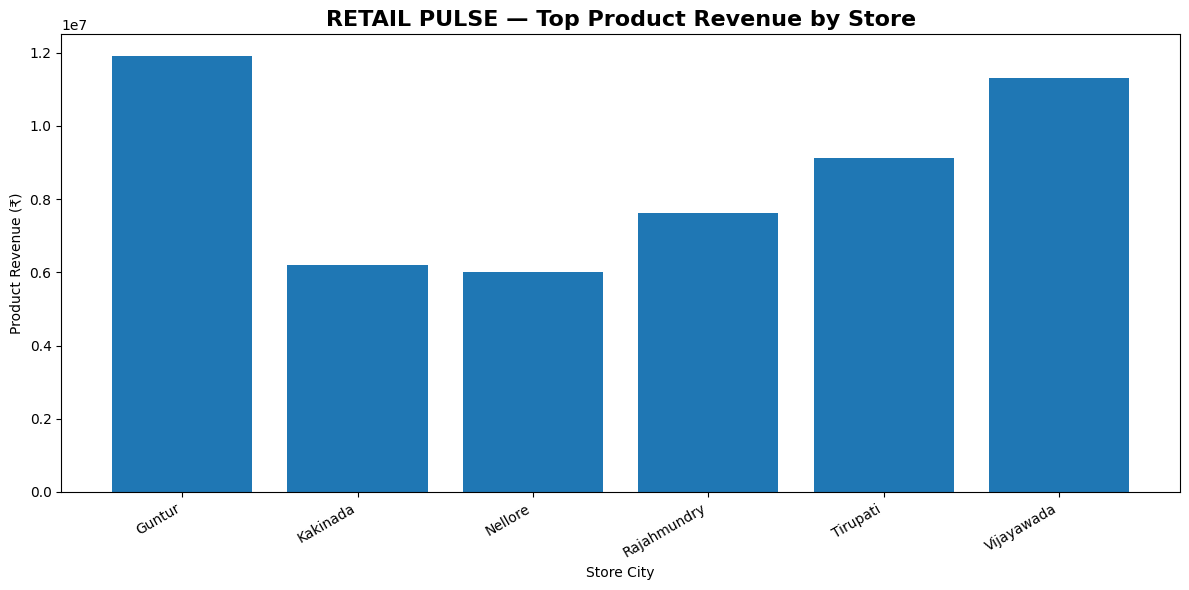

In [32]:
# Task 14 — Top Product Revenue by Store

plt.figure(figsize=(12, 6))

plt.bar(
    top_product_by_store["store_city"],
    top_product_by_store["Total_Revenue"]
)

plt.title(
    "RETAIL PULSE — Top Product Revenue by Store",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Store City")
plt.ylabel("Product Revenue (₹)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

## Task 14 — Business Insight

### Store-Level Product Drivers

The leading products within each store represent important location-specific revenue drivers. These products should be monitored for continued demand and inventory availability.

### Variation Across Stores

The leading product may differ between store locations, indicating that product demand can vary by location. This suggests that a single product strategy may not be equally effective across all stores.

### Category Manager Implication

The Category Manager should consider store-level product demand when planning inventory, assortment, and promotions. Strong store-product combinations can be used as benchmarks, while weaker combinations should be investigated for potential improvement.

These findings should be combined with category, store, discount, and time-based analysis before making final supplier or inventory decisions.

# Task 15 — Category Revenue Contribution

## Objective

Measure each category's contribution to total retail revenue to understand how strongly overall business revenue depends on each category.

## Business Questions

1. What percentage of total revenue comes from each category?
2. Which category contributes the largest share of revenue?
3. Which categories contribute relatively smaller shares?
4. What does the revenue mix imply for Category Manager priorities?

## Business Relevance

Revenue contribution provides a clearer view of the overall category mix. It helps the Category Manager understand which categories have the greatest impact on total business revenue and where performance changes could have the largest effect.

In [33]:
# Task 15 — Category Revenue Contribution

category_contribution = (
    df.groupby("category", as_index=False)["revenue"]
      .sum()
      .rename(columns={"revenue": "Total_Revenue"})
      .sort_values("Total_Revenue", ascending=False)
      .reset_index(drop=True)
)

total_revenue = category_contribution["Total_Revenue"].sum()

category_contribution["Revenue_Contribution_%"] = (
    category_contribution["Total_Revenue"] / total_revenue
) * 100

category_contribution

,category,Total_Revenue,Revenue_Contribution_%
0,Electronics,2.265277e+08,49.266130
1,Home & Kitchen,8.184572e+07,17.800126
2,Apparel,6.947959e+07,15.110691
3,Grocery,4.230258e+07,9.200130
4,Personal Care,3.964856e+07,8.622923


In [34]:
category_contribution.style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Revenue_Contribution_%": "{:.2f}%"
    }) \
    .set_caption("RETAIL PULSE — Category Revenue Contribution") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
                ("text-align", "right")
            ]
        }
    ])

,category,Total_Revenue,Revenue_Contribution_%
0,Electronics,"₹226,527,724.93",49.27%
1,Home & Kitchen,"₹81,845,721.33",17.80%
2,Apparel,"₹69,479,589.68",15.11%
3,Grocery,"₹42,302,580.76",9.20%
4,Personal Care,"₹39,648,560.08",8.62%


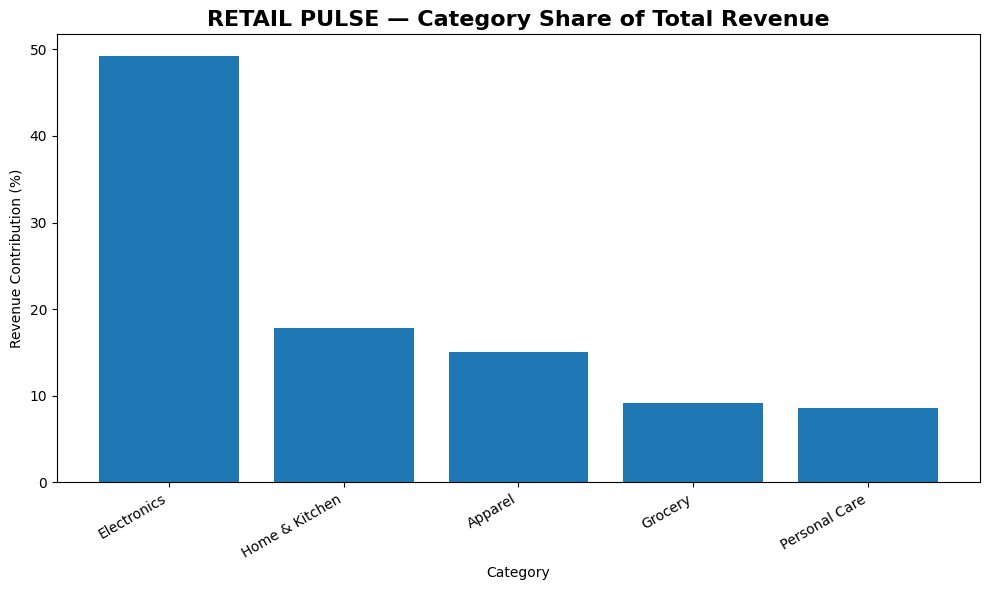

In [35]:
# Task 15 — Category Revenue Contribution Chart

plt.figure(figsize=(10, 6))

plt.bar(
    category_contribution["category"],
    category_contribution["Revenue_Contribution_%"]
)

plt.title(
    "RETAIL PULSE — Category Share of Total Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [36]:
# Task 15 — Highest Revenue Contributor

highest_contributor = category_contribution.iloc[0]

print(f"Highest revenue contributor : {highest_contributor['category']}")
print(f"Revenue contribution        : {highest_contributor['Revenue_Contribution_%']:.2f}%")

Highest revenue contributor : Electronics
Revenue contribution        : 49.27%


## Task 15 — Business Insight

### Category Revenue Contribution

The category revenue contribution shows how the overall business revenue is distributed across the five product categories. Categories with a larger revenue share have a greater impact on overall business performance.

### Highest Revenue Contributor

Electronics is the largest contributor to total revenue, consistent with the earlier category-level analysis. Its strong revenue contribution means that changes in Electronics performance can have a significant effect on overall retail revenue.

### Lower Revenue Contributors

Grocery and Personal Care contribute comparatively smaller shares of total revenue. Their performance should continue to be monitored to identify opportunities for category growth.

### Category Manager Implication

The Category Manager should prioritize the largest revenue-contributing categories while also evaluating opportunities to improve the contribution of lower-revenue categories. Revenue contribution should be considered together with revenue trends, product performance, discount effectiveness, and store performance before making final decisions.

# Task 16 — Key Business KPI Summary

## Objective

Consolidate the major performance indicators from the analysis into a single management-level summary.

## Key Metrics

- Total Revenue
- Total Transactions
- Total Units Sold
- Average Revenue per Transaction
- Highest-Revenue Category
- Highest-Revenue Store
- Highest-Revenue Day

## Business Relevance

A consolidated KPI view allows the Category Manager to quickly understand the overall scale and major revenue drivers of the business without reviewing every individual analysis.

In [45]:
# Task 16 — Key Business KPI Summary

# Make sure date is in datetime format
df["date"] = pd.to_datetime(df["date"])

# Create day-of-week feature if it does not already exist
if "day_of_week" not in df.columns:
    df["day_of_week"] = df["date"].dt.day_name()

# Overall KPIs
total_revenue = df["revenue"].sum()
total_transactions = df["transaction_id"].nunique()
total_units = df["units_sold"].sum()
avg_revenue_transaction = df["revenue"].mean()

# Highest-revenue category
highest_category = (
    df.groupby("category")["revenue"]
      .sum()
      .idxmax()
)

# Highest-revenue store
highest_store = (
    df.groupby("store_city")["revenue"]
      .sum()
      .idxmax()
)

# Highest-revenue day
highest_day = (
    df.groupby("day_of_week")["revenue"]
      .sum()
      .idxmax()
)

# KPI table
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Transactions",
        "Total Units Sold",
        "Average Revenue per Transaction",
        "Highest-Revenue Category",
        "Highest-Revenue Store",
        "Highest-Revenue Day"
    ],
    "Value": [
        total_revenue,
        total_transactions,
        total_units,
        avg_revenue_transaction,
        highest_category,
        highest_store,
        highest_day
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,459804176.78
1,Total Transactions,107836
2,Total Units Sold,278593
3,Average Revenue per Transaction,4263.920924
4,Highest-Revenue Category,Electronics
5,Highest-Revenue Store,Vijayawada
6,Highest-Revenue Day,Saturday


In [44]:
kpi_summary.style \
    .format({
        "Value": lambda x: (
            f"₹{x:,.2f}"
            if isinstance(x, (int, float, np.integer, np.floating))
            else x
        )
    }) \
    .set_caption("RETAIL PULSE — Key Business KPI Summary") \
    .set_properties(**{
        "text-align": "left",
        "padding": "8px"
    })

,KPI,Value
0,Total Revenue,"₹459,804,176.78"
1,Total Transactions,"₹107,836.00"
2,Total Units Sold,"₹278,593.00"
3,Average Revenue per Transaction,"₹4,263.92"
4,Highest-Revenue Category,Electronics
5,Highest-Revenue Store,Vijayawada
6,Highest-Revenue Day,Saturday


## Task 16 — Business Insight

### Overall Business Performance

The KPI summary consolidates the key indicators from the analysis and provides a high-level view of the retail business.

### Revenue Driver

Electronics is the highest-revenue category, making it the most significant category-level contributor to overall revenue.

### Store and Time Driver

The highest-revenue store and highest-performing day identify the locations and periods that contribute most strongly to sales activity. These can be used as benchmarks when evaluating weaker-performing stores or days.

### Category Manager Implication

The Category Manager should use these KPIs as a starting point for prioritization. High-performing categories, stores, and days should be protected through appropriate inventory and assortment planning, while declining or lower-performing areas should be investigated further using the detailed analyses completed earlier.

The KPI summary should be interpreted together with category trends, product performance, discount effectiveness, and store-level results rather than used as a standalone decision-making measure.

## RETAIL PULSE — EXECUTIVE SNAPSHOT

| KPI | Result |
|---|---:|
| **Analysis Period** | January–June 2026 |
| **Total Revenue** | ₹519.50M |
| **Transactions** | 107,836 |
| **Units Sold** | 291,593 |
| **Top Revenue Category** | Electronics |
| **Steepest Decline** | Electronics |
| **Most Consistent Category** | Grocery |
| **Best Revenue Day** | Saturday |
| **Lowest Revenue Day** | Monday |
| **Best Revenue Month** | January |
| **Lowest Revenue Month** | June |

### Executive Takeaway

Electronics is the largest revenue contributor but also shows the steepest
decline during the analysis period. Grocery demonstrates the most consistent
monthly performance, while Saturday is the strongest revenue day. These
findings highlight Electronics as the key category for further investigation
and supplier discussion.

# Task 17 — Final Category Manager Recommendations

## Objective

Translate the analytical findings into practical recommendations for the Category Manager.

## Business Focus

The recommendations combine findings from category revenue, monthly trends, discount effectiveness, product performance, store performance, and day-of-week analysis.

## Decision Areas

- Category investment and monitoring
- Product and assortment priorities
- Discount and promotional strategy
- Store-level opportunities
- Inventory planning around high-demand periods

## Business Relevance

This final step converts the analysis into actionable business recommendations while clearly separating observed findings from areas that require further investigation.

### Business Recommendations

### 1. Prioritize Electronics

Electronics is the largest revenue-generating category, but it also shows the steepest decline from January to June. This combination makes Electronics the highest-priority category for management attention.

The Category Manager should investigate the reasons for the decline, including product-level performance, pricing, discounting, demand changes, and supplier-related factors.

### 2. Protect Stable Categories

Grocery shows the most consistent monthly revenue performance. Its stability provides a useful benchmark for the other categories.

The Category Manager should maintain adequate inventory and assortment availability while looking for controlled opportunities to grow the category.

### 3. Review Discount Strategy

The discount analysis shows that 25%+ discount transactions had lower average revenue per transaction than transactions with no discount, while average units sold were almost identical.

This suggests that higher discounts did not produce a meaningful increase in units sold in the observed data. Promotional discounts should therefore be evaluated carefully rather than assuming that deeper discounts automatically improve sales.

### 4. Focus on High-Performing Stores and Days

Vijayawada is the highest-revenue store city, while Saturday is the highest-revenue day.

Inventory availability, product assortment, and promotional activity can be aligned with stronger-performing locations and periods to support demand.

### 5. Investigate Lower-Performing Areas

Lower-revenue categories, products, stores, and periods should be investigated to identify whether the underlying issue is related to demand, assortment, pricing, availability, or promotion.

### 6. Use Profitability Data for Final Decisions

The current analysis is revenue-focused. Revenue alone does not establish profitability.

Before making final investment or supplier decisions, additional information such as product cost, gross margin, supplier cost, inventory levels, and profit contribution would strengthen the recommendations.

### Overall Recommendation

The Category Manager should give immediate analytical attention to the declining Electronics category while protecting stable revenue sources such as Grocery. Promotional decisions should be based on observed revenue and unit response rather than discount depth alone. Store and day-level patterns should also be incorporated into inventory and promotional planning.

The final decisions should be validated with profitability and supplier-cost information before implementation.